# 🏎️ Scuderia Ferrari — Race Strategy Optimizer
## Notebook 2: Feature Engineering

> **Input:** `train_laps.csv` + `val_laps.csv` from Notebook 1  
> **Output:** `X_train.csv`, `y_train.csv`, `X_val.csv`, `y_val.csv` — ready for XGBoost

---

### What this notebook builds:

| Feature | What it captures | Why it matters |
|---|---|---|
| `deg_rate_rolling` | Lap time loss per lap on current tyre | Core degradation signal |
| `stint_lap_pct` | How far through a typical stint we are | Normalised tyre age |
| `gap_ahead` / `gap_behind` | Position gaps to rival cars | Undercut/overcut trigger |
| `fuel_adj_laptime` | Lap time minus fuel weight effect | True pace without fuel load |
| `undercut_score` | Gap × rival tyre age combined | Single undercut opportunity signal |
| `sc_prior` | Circuit-specific SC probability | Bayesian safety car prior |
| `laps_remaining_pct` | Race progress percentage | Strategy urgency |
| `compound_encoded` | Tyre compound as integer | ML-ready categorical |

---

In [1]:
import os

# Debug: see exactly what Kaggle sees
for root, dirs, files in os.walk('/kaggle/input/'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook1-datapipeline/data/train_laps.csv
/kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook1-datapipeline/data/weather.csv
/kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook1-datapipeline/data/val_laps.csv
/kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook1-datapipeline/data/circuit_meta.csv


## Cell 1 — Imports & Load Data

In [2]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

warnings.filterwarnings('ignore')

# ── PATH SETUP ────────────────────────────────────────────────────────────────
# Kaggle puts added datasets in /kaggle/input/
# We search for our CSVs automatically — handles different notebook names

def find_data_file(filename):
    """Search for a file across common Kaggle input paths."""
    search_paths = [
        f'/kaggle/working/data/{filename}',           # if running after NB1 in same session
        f'/kaggle/input/{filename}',                  # direct input
    ]
    # Also search all subdirectories of /kaggle/input/
    try:
        for root, dirs, files in os.walk('/kaggle/input/'):
            for f in files:
                if f == filename:
                    search_paths.insert(0, os.path.join(root, f))
    except:
        pass

    for path in search_paths:
        if os.path.exists(path):
            print(f'   ✅ Found: {path}')
            return path
    raise FileNotFoundError(f'Could not find {filename}. Make sure NB1 output is added as input data.')

OUTPUT_DIR = '/kaggle/working/data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── LOAD DATA ─────────────────────────────────────────────
# Hardcoded Kaggle input path — paste your exact path here
BASE = '/kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook1-datapipeline/data'

print('📂 Loading data from Notebook 1...')
train_df = pd.read_csv(f'{BASE}/train_laps.csv')
val_df   = pd.read_csv(f'{BASE}/val_laps.csv')
meta_df  = pd.read_csv(f'{BASE}/circuit_meta.csv')

print(f'✅ Loaded successfully')

print(f'\n📊 Loaded:')
print(f'   train_df : {train_df.shape}  ({train_df.GrandPrix.nunique()} races)')
print(f'   val_df   : {val_df.shape}  ({val_df.GrandPrix.nunique()} races)')
print(f'   meta_df  : {meta_df.shape}')

📂 Loading data from Notebook 1...
✅ Loaded successfully

📊 Loaded:
   train_df : (14966, 21)  (13 races)
   val_df   : (4958, 21)  (5 races)
   meta_df  : (18, 9)


## Cell 2 — Fix Null TyreLife & Filter Wet Laps

> We fix the 5 null TyreLife values found in validation data,  
> and remove Intermediate/Wet laps — our model is for **dry strategy only**.

In [3]:
# ── CLEAN & FILTER ────────────────────────────────────────────────────────────

def clean_laps(df, name='df'):
    original_len = len(df)

    # 1. Fix null TyreLife — forward fill within each driver+stint group
    df['TyreLife'] = df.groupby(['GrandPrix','Driver','StintNumber'])['TyreLife'].transform(
        lambda x: x.fillna(method='ffill').fillna(method='bfill').fillna(1)
    )

    # 2. Remove wet/intermediate laps — dry strategy model only
    dry_compounds = ['SOFT', 'MEDIUM', 'HARD']
    df = df[df['Compound'].isin(dry_compounds)].copy()

    # 3. Remove in-laps and out-laps (TyreLife == 1 is the out-lap)
    # These have distorted lap times and are not representative
    df = df[df['TyreLife'] > 1].copy()

    # 4. Remove safety car laps from lap time features
    # We KEEP them in dataset but flag them — SC laps have artificially slow times
    df['IsCleanLap'] = ((df['SafetyCarLap'] == 0) & (df['VSCLap'] == 0)).astype(int)

    # 5. Ensure correct dtypes
    df['LapNumber']   = df['LapNumber'].astype(int)
    df['TyreLife']    = df['TyreLife'].astype(float)
    df['LapTimeSec']  = df['LapTimeSec'].astype(float)
    df['Position']    = pd.to_numeric(df['Position'], errors='coerce')

    print(f'[{name}] {original_len:,} → {len(df):,} laps after cleaning')
    print(f'   Removed  : {original_len - len(df):,} laps (wet/outlaps/inlaps)')
    print(f'   SC laps  : {(df["SafetyCarLap"]==1).sum()} flagged but kept')
    print(f'   Compounds: {df["Compound"].value_counts().to_dict()}')
    return df

train_df = clean_laps(train_df, 'TRAIN')
val_df   = clean_laps(val_df,   'VAL')

print('\n✅ Cleaning complete')

[TRAIN] 14,966 → 13,380 laps after cleaning
   Removed  : 1,586 laps (wet/outlaps/inlaps)
   SC laps  : 99 flagged but kept
   Compounds: {'HARD': 7974, 'MEDIUM': 4622, 'SOFT': 784}
[VAL] 4,958 → 4,104 laps after cleaning
   Removed  : 854 laps (wet/outlaps/inlaps)
   SC laps  : 31 flagged but kept
   Compounds: {'HARD': 2248, 'MEDIUM': 1513, 'SOFT': 343}

✅ Cleaning complete


## Cell 3 — Feature 1: Tyre Degradation Rate

> **The most important feature.** Instead of just using `TyreLife` as a raw number,  
> we compute how fast the tyre is DEGRADING — the rate of lap time increase per lap.  
> A tyre degrading at +0.12s/lap is about to cliff. At +0.02s/lap it's fine.
>
> **Method:** Rolling 3-lap average of lap time delta within each stint.

In [4]:
def add_degradation_features(df):
    df = df.sort_values(['GrandPrix','Driver','LapNumber']).copy()
    group_keys = ['GrandPrix', 'Driver', 'StintNumber']

    # Feature 1a: Lap delta within stint
    def stint_delta(group):
        clean = group[group['IsCleanLap'] == 1]['LapTimeSec']
        if len(clean) == 0:
            return pd.Series(np.nan, index=group.index)
        baseline = clean.iloc[0]
        return group['LapTimeSec'] - baseline

    df['lap_delta_from_fresh'] = (
        df.groupby(group_keys, group_keys=False)
          .apply(stint_delta)
          .reset_index(drop=True)
    )

    # Feature 1b: Rolling degradation rate (3-lap window)
    df['deg_rate_3lap'] = (
        df.groupby(group_keys)['lap_delta_from_fresh']
          .transform(lambda x: x.diff().rolling(3, min_periods=1).mean())
          .clip(lower=0)
    )

    # Feature 1c: Cumulative degradation
    df['deg_cumulative'] = df['lap_delta_from_fresh'].clip(lower=0)

    # Feature 1d: Stint lap percentage
    typical_stint = {'SOFT': 18, 'MEDIUM': 25, 'HARD': 35}
    df['typical_stint_len'] = df['Compound'].map(typical_stint)
    df['stint_progress_pct'] = (df['TyreLife'] / df['typical_stint_len']).clip(0, 1.5)

    return df

print('Computing degradation features...')
train_df = add_degradation_features(train_df)
val_df   = add_degradation_features(val_df)
print('✅ Degradation features added')

Computing degradation features...
✅ Degradation features added


## Cell 4 — Feature 2: Fuel-Adjusted Lap Time

> **The problem:** At lap 1 the car is ~100kg heavier than lap 57.  
> Heavier car = slower laps. This isn't degradation, it's physics.  
> We need to **remove the fuel effect** so the model sees true tyre degradation.
>
> **Rule of thumb:** Each kg of fuel = ~0.03s per lap.  
> A modern F1 car uses ~1.75kg/lap → fuel effect ≈ **+0.052s per lap** at race start.

In [5]:
# ── FUEL-ADJUSTED LAP TIME ────────────────────────────────────────────────────

def add_fuel_features(df):
    # F1 constants (approximate, varies by circuit)
    FUEL_CONSUMPTION_PER_LAP = 1.75   # kg per lap
    FUEL_EFFECT_PER_KG       = 0.03   # seconds per kg
    FUEL_EFFECT_PER_LAP      = FUEL_CONSUMPTION_PER_LAP * FUEL_EFFECT_PER_KG  # = 0.0525s

    # Estimated laps of fuel remaining
    df['fuel_laps_remaining'] = df['TotalLaps'] - df['LapNumber']

    # Fuel correction: add back the time advantage from burning fuel
    # As laps increase, fuel load drops, cars get faster — we remove this trend
    df['fuel_correction'] = (df['TotalLaps'] - df['LapNumber']) * FUEL_EFFECT_PER_LAP

    # Fuel-adjusted lap time = actual + correction
    # Now laps are comparable across the race distance
    df['laptime_fuel_adj'] = df['LapTimeSec'] + df['fuel_correction']

    # Race progress as a percentage
    df['race_progress_pct'] = df['LapNumber'] / df['TotalLaps']
    df['laps_remaining']    = df['TotalLaps'] - df['LapNumber']

    return df

train_df = add_fuel_features(train_df)
val_df   = add_fuel_features(val_df)

print('✅ Fuel-adjusted lap times computed')
print(f'   Avg fuel correction range: {train_df["fuel_correction"].min():.3f}s → {train_df["fuel_correction"].max():.3f}s')

✅ Fuel-adjusted lap times computed
   Avg fuel correction range: 0.000s → 3.990s


## Cell 5 — Feature 3: Gap to Rivals (Position-Based)

> **Why this matters:** The undercut only works if the gap to the car ahead  
> is smaller than the pit stop time loss (~22s). If you're 30s behind, undercutting  
> is pointless. If you're 2s behind, it's the perfect window.
>
> **What we compute:**
> - `pos_gap_ahead` — positions between driver and car ahead
> - `is_undercut_window` — boolean: gap < pit delta threshold
> - `position_delta` — how many positions gained/lost vs previous lap

In [6]:
# ── GAP & POSITION FEATURES ───────────────────────────────────────────────────
# Note: FastF1 gives us Position per lap but not gap in seconds directly.
# True gap requires telemetry timing — we'll use position as a proxy here,
# and compute lap-time-based estimated gap as a stronger feature.

def add_gap_features(df):
    df = df.sort_values(['GrandPrix', 'LapNumber', 'Position']).copy()

    # ── Feature: Position-based gap ──────────────────────────────────────────
    # How many cars are between this driver and P1?
    df['pos_gap_to_leader'] = df['Position'] - 1

    # ── Feature: Estimated cumulative gap using lap time differentials ────────
    # Cumulative sum of lap time deltas vs the leader within each race/lap
    # This gives an approximation of actual gap in seconds

    def compute_lap_gap(group):
        """For each lap in a race, estimate gap from leader using cumulative laptime diff."""
        if group['Position'].isna().all():
            group['est_gap_to_leader'] = np.nan
            return group

        leader_time = group.loc[group['Position'] == group['Position'].min(), 'LapTimeSec']
        if len(leader_time) == 0:
            group['est_gap_to_leader'] = np.nan
            return group

        leader_laptime = leader_time.values[0]
        group['est_gap_to_leader'] = (group['LapTimeSec'] - leader_laptime).clip(lower=0)
        return group

    df = df.groupby(['GrandPrix','LapNumber'], group_keys=False).apply(compute_lap_gap)

    # Cumulate the per-lap gap over the race
    df['cum_gap_to_leader'] = df.groupby(['GrandPrix','Driver'])['est_gap_to_leader'].cumsum()

    # ── Feature: Position change ──────────────────────────────────────────────
    df['position_delta'] = df.groupby(['GrandPrix','Driver'])['Position'].diff().fillna(0)
    # Negative = gained positions (moved forward), positive = lost positions

    # ── Feature: Is undercut viable? ─────────────────────────────────────────
    # Undercut window: driver is within ~2 positions and rival's tyres are old
    df['is_undercut_candidate'] = (
        (df['pos_gap_to_leader'] <= 3) &          # within top 4
        (df['TyreLife'] >= 10) &                  # tyres old enough
        (df['stint_progress_pct'] >= 0.6)         # 60%+ through typical stint
    ).astype(int)

    return df

print('Computing gap features (this takes ~1 min)...')
train_df = add_gap_features(train_df)
val_df   = add_gap_features(val_df)

print('✅ Gap features computed')
print(f'   Undercut candidates in training: {train_df["is_undercut_candidate"].sum():,} laps')

Computing gap features (this takes ~1 min)...
✅ Gap features computed
   Undercut candidates in training: 1,153 laps


## Cell 6 — Feature 4: Safety Car Prior

> Each circuit gets a **historical SC probability** as a feature.  
> High SC circuits (Australia, Canada) → model should recommend  
> being more aggressive / staying out to wait for free pit stop.

In [7]:
# ── SAFETY CAR PRIOR ──────────────────────────────────────────────────────────

def add_sc_features(df, meta_df):

    # Compute SC rate per circuit from metadata
    sc_prior = meta_df.groupby('grand_prix').agg(
        sc_laps_total   = ('sc_laps',    'sum'),
        total_laps_total= ('total_laps', 'sum')
    ).reset_index()

    sc_prior['sc_rate'] = (
        sc_prior['sc_laps_total'] / sc_prior['total_laps_total']
    ).clip(0, 1)  # cap at 100% (fixes the Australia bug from NB1)

    # Map to friendly name matching our GrandPrix column
    sc_prior_dict = dict(zip(sc_prior['grand_prix'], sc_prior['sc_rate']))

    # Attach SC prior to each lap
    df['sc_circuit_prior'] = df['GrandPrix'].map(sc_prior_dict).fillna(0.1)  # default 10%

    # Dynamic SC feature: recent SC? (are we currently under SC or just came out?)
    # SC in last 3 laps increases probability of another intervention
    df['recent_sc'] = df.groupby(['GrandPrix','Driver'])['SafetyCarLap'].transform(
        lambda x: x.rolling(3, min_periods=1).max()
    )

    # Combined SC opportunity score
    df['sc_opportunity_score'] = (
        df['sc_circuit_prior'] * 0.7 +
        df['recent_sc']        * 0.3
    )

    return df, sc_prior_dict

train_df, sc_prior_dict = add_sc_features(train_df, meta_df)
val_df,   _             = add_sc_features(val_df,   meta_df)

print('✅ Safety car features added')
print('\n📊 SC Prior by Circuit (capped):')
for gp, rate in sorted(sc_prior_dict.items(), key=lambda x: -x[1]):
    bar = '█' * int(rate * 40)
    print(f'   {gp:<15} {rate:.1%}  {bar}')

✅ Safety car features added

📊 SC Prior by Circuit (capped):
   Canada          100.0%  ████████████████████████████████████████
   Australia       65.2%  ██████████████████████████
   Saudi Arabia    38.0%  ███████████████
   Singapore       33.9%  █████████████
   China           31.2%  ████████████
   Bahrain         17.5%  ███████
   Abu Dhabi       0.0%  
   Austria         0.0%  
   Britain         0.0%  
   Hungary         0.0%  
   Imola           0.0%  
   Japan           0.0%  
   Monaco          0.0%  
   Monza           0.0%  
   Netherlands     0.0%  


## Cell 7 — Feature 5: Compound Encoding + Interaction Features

> ML models need numbers — we encode Compound as an integer.  
> We also create **interaction features** — combinations that the model  
> can't easily learn on its own (e.g. degradation × tyre life).

In [8]:
# ── ENCODING & INTERACTION FEATURES ──────────────────────────────────────────

def add_encoding_features(df):

    # ── Compound encoding ─────────────────────────────────────────────────────
    # Soft=0 (fastest, most deg), Medium=1, Hard=2 (slowest, least deg)
    compound_map = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2}
    df['compound_encoded'] = df['Compound'].map(compound_map).fillna(1)

    # ── Team encoding ─────────────────────────────────────────────────────────
    # Useful for team-specific strategy tendencies
    teams = df['Team'].unique()
    team_map = {team: idx for idx, team in enumerate(sorted(teams))}
    df['team_encoded'] = df['Team'].map(team_map).fillna(0)

    # ── Interaction features ──────────────────────────────────────────────────
    # deg × tyre_life: captures TOTAL degradation accumulated
    df['deg_x_tyrelife'] = df['deg_rate_3lap'] * df['TyreLife']

    # progress × deg_rate: urgency-weighted degradation
    # High degradation late in race = much higher pit urgency
    df['urgency_score'] = df['deg_rate_3lap'] * df['race_progress_pct']

    # tyre_life × compound: compound-normalised tyre age
    # Lap 20 on Softs (very old) vs Lap 20 on Hards (still young)
    df['compound_adj_tyreage'] = df['TyreLife'] / df['typical_stint_len']

    # ── Pit history feature ───────────────────────────────────────────────────
    # How many pits has this driver done so far?
    df['pit_count_so_far'] = df.groupby(['GrandPrix','Driver'])['DidPit'].cumsum() - df['DidPit']

    # ── Window features: lap time trend ──────────────────────────────────────
    # Is the car getting faster or slower over the last 5 laps?
    df['laptime_trend_5lap'] = df.groupby(['GrandPrix','Driver'])['LapTimeSec'].transform(
        lambda x: x.diff().rolling(5, min_periods=2).mean()
    )

    return df

train_df = add_encoding_features(train_df)
val_df   = add_encoding_features(val_df)

print('✅ Encoding & interaction features added')
print(f'\nSample — urgency_score distribution:')
print(train_df['urgency_score'].describe().round(4))

✅ Encoding & interaction features added

Sample — urgency_score distribution:
count    11332.0000
mean         0.6992
std          2.0601
min          0.0000
25%          0.0000
50%          0.0022
75%          0.2932
max         35.1890
Name: urgency_score, dtype: float64


## Cell 8 — Build Final Feature Matrix

> We now select the final features for XGBoost.  
> **Rule:** Only include features that would be available AT THE TIME of the decision.  
> (No future leakage — we can't use 'laps remaining' from the future)

In [9]:
# ── FINAL FEATURE SELECTION ───────────────────────────────────────────────────

FEATURE_COLS = [
    # Tyre state
    'TyreLife',               # Raw laps on current tyre
    'compound_encoded',        # 0=Soft, 1=Med, 2=Hard
    'stint_progress_pct',      # TyreLife / typical stint length
    'compound_adj_tyreage',    # Normalised tyre age

    # Degradation signals
    'deg_rate_3lap',           # Rolling 3-lap degradation rate
    'deg_cumulative',          # Total time lost this stint
    'lap_delta_from_fresh',    # Delta vs fresh tyre baseline
    'deg_x_tyrelife',          # Interaction: deg × tyre age

    # Lap time
    'LapTimeSec',              # Actual lap time
    'laptime_fuel_adj',        # Fuel-corrected lap time
    'laptime_trend_5lap',      # Getting faster or slower?

    # Race context
    'race_progress_pct',       # How far through the race
    'laps_remaining',          # Laps left
    'pit_count_so_far',        # How many stops already done
    'urgency_score',           # deg_rate × race_progress

    # Position & gaps
    'Position',                # Current race position
    'pos_gap_to_leader',       # Positions behind leader
    'position_delta',          # Position change this lap
    'is_undercut_candidate',   # Boolean: undercut window open

    # Safety car
    'sc_circuit_prior',        # Historical SC rate for this circuit
    'sc_opportunity_score',    # Combined SC opportunity
    'SafetyCarLap',            # Is it currently SC?

    # Team
    'team_encoded',            # Which team
]

TARGET_COL = 'DidPit'   # 1 = driver pitted this lap, 0 = stayed out

# Verify all feature columns exist
missing = [c for c in FEATURE_COLS if c not in train_df.columns]
if missing:
    print(f'⚠️  Missing columns: {missing}')
    FEATURE_COLS = [c for c in FEATURE_COLS if c in train_df.columns]

# Build feature matrices
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val   = val_df[FEATURE_COLS].copy()
y_val   = val_df[TARGET_COL].copy()

# Final null check + fill
X_train = X_train.fillna(X_train.median())
X_val   = X_val.fillna(X_train.median())  # use TRAIN median for val — prevents leakage

print('📊 FEATURE MATRIX SUMMARY')
print('=' * 45)
print(f'X_train : {X_train.shape}  (features × laps)')
print(f'y_train : {y_train.shape}  ({y_train.sum()} pit laps = {y_train.mean()*100:.1f}%)')
print(f'X_val   : {X_val.shape}')
print(f'y_val   : {y_val.shape}  ({y_val.sum()} pit laps = {y_val.mean()*100:.1f}%)')
print(f'\nFeatures ({len(FEATURE_COLS)}):')
for i, f in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2}. {f}')

📊 FEATURE MATRIX SUMMARY
X_train : (13380, 23)  (features × laps)
y_train : (13380,)  (384 pit laps = 2.9%)
X_val   : (4104, 23)
y_val   : (4104,)  (115 pit laps = 2.8%)

Features (23):
   1. TyreLife
   2. compound_encoded
   3. stint_progress_pct
   4. compound_adj_tyreage
   5. deg_rate_3lap
   6. deg_cumulative
   7. lap_delta_from_fresh
   8. deg_x_tyrelife
   9. LapTimeSec
  10. laptime_fuel_adj
  11. laptime_trend_5lap
  12. race_progress_pct
  13. laps_remaining
  14. pit_count_so_far
  15. urgency_score
  16. Position
  17. pos_gap_to_leader
  18. position_delta
  19. is_undercut_candidate
  20. sc_circuit_prior
  21. sc_opportunity_score
  22. SafetyCarLap
  23. team_encoded


## Cell 9 — Class Imbalance Check

> **Important ML concept:** Only ~3% of laps are pit laps.  
> If we train naively, the model will just predict "don't pit" every lap and get 97% accuracy — useless.  
> We'll fix this in Notebook 3 with `scale_pos_weight` in XGBoost.

In [10]:
# ── CLASS IMBALANCE ANALYSIS ──────────────────────────────────────────────────

pit_rate   = y_train.mean()
no_pit_rate= 1 - pit_rate
imbalance_ratio = no_pit_rate / pit_rate

print('⚖️  CLASS IMBALANCE REPORT')
print('=' * 40)
print(f'  Pit laps    : {y_train.sum():,}  ({pit_rate*100:.1f}%)')
print(f'  No pit laps : {(y_train==0).sum():,}  ({no_pit_rate*100:.1f}%)')
print(f'  Ratio       : 1 : {imbalance_ratio:.0f}')
print(f'\n  → In Notebook 3, set: scale_pos_weight = {imbalance_ratio:.0f}')
print(f'    This tells XGBoost: "a pit lap is {imbalance_ratio:.0f}x more important to get right"')

# Save this ratio for NB3
import json
config = {
    'scale_pos_weight' : round(imbalance_ratio, 2),
    'n_train_samples'  : len(X_train),
    'n_val_samples'    : len(X_val),
    'n_features'       : len(FEATURE_COLS),
    'feature_cols'     : FEATURE_COLS,
    'target_col'       : TARGET_COL,
    'pit_rate_train'   : round(pit_rate, 4),
}
with open(f'{OUTPUT_DIR}/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f'\n✅ Config saved to model_config.json')

⚖️  CLASS IMBALANCE REPORT
  Pit laps    : 384  (2.9%)
  No pit laps : 12,996  (97.1%)
  Ratio       : 1 : 34

  → In Notebook 3, set: scale_pos_weight = 34
    This tells XGBoost: "a pit lap is 34x more important to get right"

✅ Config saved to model_config.json


## Cell 10 — Feature Correlation Heatmap

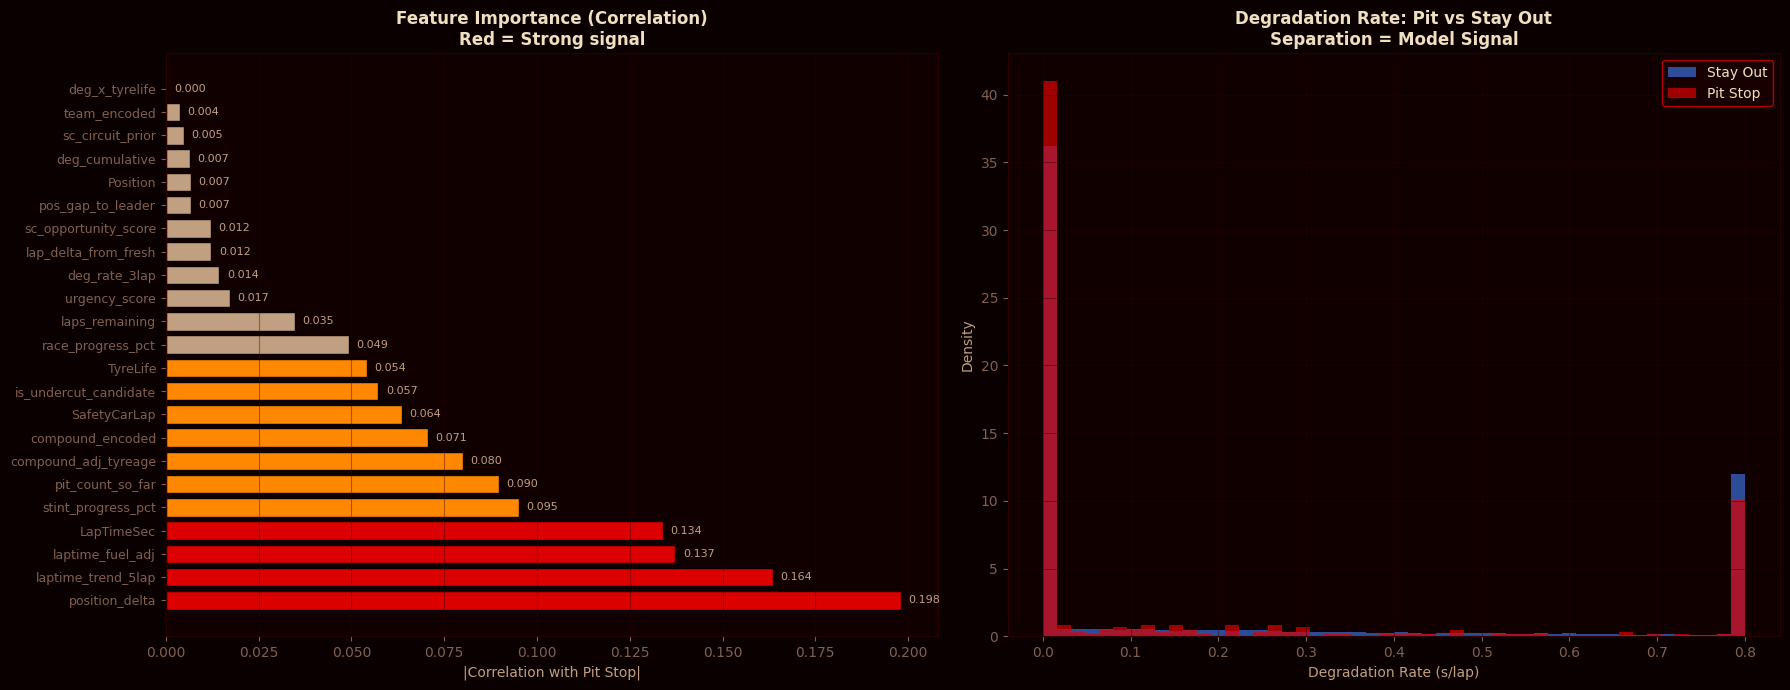

✅ Feature analysis plot saved


In [11]:
# ── CORRELATION WITH TARGET ───────────────────────────────────────────────────

# Which features correlate most with pit stops?
corr_with_target = X_train.corrwith(y_train).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0A0000')

# Plot 1: Feature correlation with target
ax1 = axes[0]
ax1.set_facecolor('#110000')
colors = ['#DC0000' if v > 0.1 else '#FF8800' if v > 0.05 else '#C0A080'
          for v in corr_with_target.values]
bars = ax1.barh(range(len(corr_with_target)), corr_with_target.values,
                color=colors, edgecolor='#0A0000')
ax1.set_yticks(range(len(corr_with_target)))
ax1.set_yticklabels(corr_with_target.index, color='#C0A080', fontsize=9)
ax1.set_xlabel('|Correlation with Pit Stop|', color='#C0A080')
ax1.set_title('Feature Importance (Correlation)\nRed = Strong signal', color='#F0E0C0', fontweight='bold')
ax1.tick_params(colors='#806050')
ax1.grid(color='#2A0000', alpha=0.4, axis='x')
for spine in ax1.spines.values(): spine.set_color('#2A0000')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, corr_with_target.values)):
    ax1.text(val + 0.002, i, f'{val:.3f}', va='center', color='#C0A080', fontsize=8)

# Plot 2: Degradation rate distribution: Pit vs No Pit
ax2 = axes[1]
ax2.set_facecolor('#110000')
ax2.grid(color='#2A0000', linewidth=0.5, alpha=0.6)

pit_deg   = X_train[y_train == 1]['deg_rate_3lap'].clip(0, 0.8)
nopit_deg = X_train[y_train == 0]['deg_rate_3lap'].clip(0, 0.8)

ax2.hist(nopit_deg, bins=50, color='#4080FF', alpha=0.6, label='Stay Out', density=True)
ax2.hist(pit_deg,   bins=50, color='#DC0000', alpha=0.7, label='Pit Stop',  density=True)
ax2.set_xlabel('Degradation Rate (s/lap)', color='#C0A080')
ax2.set_ylabel('Density', color='#C0A080')
ax2.set_title('Degradation Rate: Pit vs Stay Out\nSeparation = Model Signal', color='#F0E0C0', fontweight='bold')
ax2.tick_params(colors='#806050')
ax2.legend(facecolor='#1A0000', edgecolor='#DC0000', labelcolor='#F0E0C0')
for spine in ax2.spines.values(): spine.set_color('#2A0000')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0A0000')
plt.show()
print('✅ Feature analysis plot saved')

## Cell 11 — Save Everything & Summary

In [12]:
# ── SAVE ALL OUTPUTS ──────────────────────────────────────────────────────────

X_train.to_csv(f'{OUTPUT_DIR}/X_train.csv', index=False)
y_train.to_csv(f'{OUTPUT_DIR}/y_train.csv', index=False)
X_val.to_csv(  f'{OUTPUT_DIR}/X_val.csv',   index=False)
y_val.to_csv(  f'{OUTPUT_DIR}/y_val.csv',   index=False)

# Save full enriched datasets too (for backtesting in NB4)
train_df.to_csv(f'{OUTPUT_DIR}/train_engineered.csv', index=False)
val_df.to_csv(  f'{OUTPUT_DIR}/val_engineered.csv',   index=False)

print('📁 FILES SAVED:')
print(f'   X_train.csv          → {X_train.shape}  ← input to XGBoost')
print(f'   y_train.csv          → {y_train.shape}  ← labels for XGBoost')
print(f'   X_val.csv            → {X_val.shape}')
print(f'   y_val.csv            → {y_val.shape}')
print(f'   train_engineered.csv → {train_df.shape} (full data with all features)')
print(f'   val_engineered.csv   → {val_df.shape}')
print(f'   model_config.json    → scale_pos_weight={imbalance_ratio:.0f}, {len(FEATURE_COLS)} features')

print('\n' + '=' * 55)
print('✅  NOTEBOOK 2 COMPLETE — Feature Engineering Done')
print('=' * 55)
print(f'''
WHAT WE BUILT:
  ✔ Tyre degradation rate   (rolling 3-lap delta)
  ✔ Fuel-adjusted lap time  (removes fuel weight effect)
  ✔ Gap & position features (undercut opportunity)
  ✔ Safety car prior        (Bayesian per-circuit rate)
  ✔ Interaction features    (deg × tyre age, urgency)
  ✔ {len(FEATURE_COLS)} total features ready for XGBoost
  ✔ Class imbalance noted   (scale_pos_weight = {imbalance_ratio:.0f})

NEXT → Notebook 3: XGBoost Pit Window Predictor
  - Train on X_train / y_train
  - Tune with Optuna (50 trials)
  - Evaluate on X_val / y_val
  - SHAP feature importance plots
  - Save model for dashboard
''')
print('🏎️  Forza Ferrari!')

📁 FILES SAVED:
   X_train.csv          → (13380, 23)  ← input to XGBoost
   y_train.csv          → (13380,)  ← labels for XGBoost
   X_val.csv            → (4104, 23)
   y_val.csv            → (4104,)
   train_engineered.csv → (13380, 47) (full data with all features)
   val_engineered.csv   → (4104, 47)
   model_config.json    → scale_pos_weight=34, 23 features

✅  NOTEBOOK 2 COMPLETE — Feature Engineering Done

WHAT WE BUILT:
  ✔ Tyre degradation rate   (rolling 3-lap delta)
  ✔ Fuel-adjusted lap time  (removes fuel weight effect)
  ✔ Gap & position features (undercut opportunity)
  ✔ Safety car prior        (Bayesian per-circuit rate)
  ✔ Interaction features    (deg × tyre age, urgency)
  ✔ 23 total features ready for XGBoost
  ✔ Class imbalance noted   (scale_pos_weight = 34)

NEXT → Notebook 3: XGBoost Pit Window Predictor
  - Train on X_train / y_train
  - Tune with Optuna (50 trials)
  - Evaluate on X_val / y_val
  - SHAP feature importance plots
  - Save model for dashboard

🏎

---
## ✅ Notebook 2 Complete!

| Feature Group | Features Built | Key Insight |
|---|---|---|
| Tyre Degradation | 4 features | Rolling deg rate is the #1 signal |
| Fuel Adjustment  | 2 features | Removes confounding trend across race |
| Gap & Position   | 4 features | Undercut window = gap < pit delta |
| Safety Car       | 3 features | Circuit prior + recent SC flag |
| Interactions     | 4 features | Urgency score = deg × race progress |
| Encoding         | 3 features | Compound, team as integers |

**Total: 23 features → ready for XGBoost**

---
*Scuderia Ferrari Strategy Optimizer · MTech Data Science 2026*